### Model inspired by:

- [1] Offshore Pipelaying Dynamics. Gullik Anthon Jensen
- [2] A nonlinear PDE formulation for offshore vessel pipeline installation. Gullik A. Jensen et al
- [3] Modeling and Control of Offshore Pipelay Operations Based on a Finite Strain Pipe Model. Gullik A. Jensen

### Implementation aspects:

- The model can be applied to normal dynamic pipelay condition as a rough estimate

In [1]:
import numpy as np
import inspect
import matplotlib.pyplot as plt
import scipy
from datetime import datetime
from scipy.optimize import root
from scipy.integrate import solve_ivp
from scipy import interpolate
import plotly.graph_objects as go
from scipy.interpolate import interp1d

In [2]:
import sys

In [3]:
sys.path.insert(0, "../../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src/python_vehicle_simulator")
sys.path.insert(0, "../../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src")

In [4]:
from python_vehicle_simulator.vehicles import *
from python_vehicle_simulator.lib import *
from python_vehicle_simulator.lib.gnc import ssa

### Modelling data:

In [5]:
mp = 41.9       #  (submerged pipe weight) [kg/m]
N = 50       # number of modelling nodes

In [6]:
mi = [mp for i in range(N)]

In [7]:
# Vessel:

# L - the hull length
# Xg - x-center of gravity

L = 168 # [m]
B = 46
H = 13.5
Xg = L/2 # [m]
mn = 39_989_000  # mass of the vessel, [kg]

In [8]:
Fx_0 = 449*1000
Fy_0 = 0.7*Fx_0
LTD = 387

In [9]:
lx, ly, lz = L/2, B/2, H/2

In [10]:
vessel_mass = mn/L # mass over length of the vessel

In [11]:
diag_Jrho0 = 1e2*np.array([1, 1, 2]) # [m^4] 
Jrho0 = np.diag(diag_Jrho0)

In [12]:
qw = 1025 # Water density [kg/m3]
d0 = 0.2731 # Outer diameter of pipe, [m]
dI= (273.1-15.9*2)/1000 # Inner diameter of pipe, [m]

In [13]:
rho_steel=7850 #kg/m^3

In [14]:
Ar=np.pi*(d0/2)**2

Iy_ = 1/4*np.pi*rho_steel*((d0/2)**4-(dI/2)**4)
Iz_ = 1/2*np.pi*rho_steel*((d0/2)**4-(dI/2)**4)
J_ = 1/32*np.pi*(d0**4-dI**4)

In [15]:
E = 207e9
G = 79.3e9

In [16]:
h = 90 # water depth

In [17]:
# Fossen book p.181
def vessel_inertia_moment(mn, Xg, L):
    r = 0.25*L
    Ir = mn*r**2
    Iz=mn*Xg**2 + Ir
    return Iz

In [18]:
vessel_inertia = vessel_inertia_moment(mn, Xg, L)

In [19]:
# Underwater current: 
dv1_curr = np.zeros(N)
dv2_curr = np.zeros(N)
dv3_curr = np.zeros(N)

In [20]:
# Constants: 

In [21]:
diag_DT = 1.5*np.array([1, 1, 1])
DT=np.diag(diag_DT)

In [22]:
diag_CT = 1e9*np.array([1, 1, 1 ])  
CT=np.diag(diag_CT)

In [23]:
# diag_CR = 1e11*np.array([1, 1, 1]) 
diag_CR = 1e9*np.array([1, 1, 1])        ### !!! ### !!! ### !!! ### affects bending strain                
CR=np.diag(diag_CR)

In [24]:
diag_DR = 1.5*np.array([1, 1, 1])
DR=np.diag(diag_DR)

In [25]:
# for testing:

In [26]:
φ = np.random.rand(N)
θ = np.random.rand(N)
ψ = np.random.rand(N)

In [27]:
φ

array([0.17521536, 0.68068012, 0.90643086, 0.36596638, 0.43793188,
       0.06799993, 0.98594658, 0.36697146, 0.61225787, 0.96497483,
       0.59498137, 0.63646003, 0.59883052, 0.41114507, 0.25253227,
       0.83575655, 0.06695488, 0.04421998, 0.98028806, 0.54920272,
       0.42646101, 0.73742163, 0.04428632, 0.91666686, 0.78374251,
       0.56083731, 0.56088813, 0.05524541, 0.12373618, 0.79863919,
       0.13937654, 0.5735836 , 0.10194236, 0.95953133, 0.24312023,
       0.072803  , 0.39975761, 0.88248886, 0.22565026, 0.35306501,
       0.43710081, 0.35390044, 0.20033525, 0.70158456, 0.332869  ,
       0.17394431, 0.51424589, 0.33258921, 0.7828726 , 0.57987196])

In [28]:
dφ = np.random.rand(N)
dθ = np.random.rand(N)
dψ = np.random.rand(N)

In [29]:
ddφ = np.random.rand(N)
ddθ = np.random.rand(N)
ddψ = np.random.rand(N)

In [30]:
x = np.random.rand(N)
y = np.random.rand(N)
z = np.random.rand(N)

In [31]:
dx = np.random.rand(N)
dy = np.random.rand(N)
dz = np.random.rand(N)

In [32]:
# integration parameters
tspan = (0., 10)

### Main functions:

In [33]:
def Π0(φθψ):
    φ0,θ0,ψ0=φθψ
    return np.array([[np.cos(θ0),0,np.cos(φ0)*np.sin(θ0)],
                  [0,1,-np.sin(φ0)],
                  [-np.sin(θ0),0,np.cos(φ0)*np.cos(θ0)]])

In [34]:
def Π(φ,θ,ψ):
    φθψ=np.stack((φ,θ,ψ), axis=1)
    return np.apply_along_axis(Π0, 1, φθψ)

In [35]:
Π(φ,θ,ψ)

array([[[ 0.79878367,  0.        ,  0.59240699],
        [ 0.        ,  1.        , -0.17432021],
        [-0.60161836,  0.        ,  0.78655351]],

       [[ 0.84301004,  0.        ,  0.41802455],
        [ 0.        ,  1.        , -0.62932172],
        [-0.53789783,  0.        ,  0.65514093]],

       [[ 0.83173821,  0.        ,  0.34229422],
        [ 0.        ,  1.        , -0.78730817],
        [-0.55516803,  0.        ,  0.51281625]],

       [[ 0.94394596,  0.        ,  0.30824026],
        [ 0.        ,  1.        , -0.35785184],
        [-0.33010001,  0.        ,  0.88143633]],

       [[ 0.98731949,  0.        ,  0.14376506],
        [ 0.        ,  1.        , -0.42406742],
        [-0.1587458 ,  0.        ,  0.89414676]],

       [[ 0.97709712,  0.        ,  0.21230203],
        [ 0.        ,  1.        , -0.06794754],
        [-0.21279382,  0.        ,  0.97483895]],

       [[ 0.99635418,  0.        ,  0.04709921],
        [ 0.        ,  1.        , -0.83379504],
        

In [36]:
def dΠ0(φ0, θ0, ψ0, dφ0, dθ0, dψ0):
    """Time derivative of Π0 via chain rule: dΠ/dt = ∂Π/∂φ·dφ + ∂Π/∂θ·dθ + ∂Π/∂ψ·dψ"""
    
    # ∂Π/∂φ
    dPi_dphi = np.array([
        [0,              0,  -np.sin(φ0)*np.sin(θ0)],
        [0,              0,  -np.cos(φ0)            ],
        [0,              0,  -np.sin(φ0)*np.cos(θ0)]
    ])
    
    # ∂Π/∂θ
    dPi_dtheta = np.array([
        [-np.sin(θ0),   0,   np.cos(φ0)*np.cos(θ0)],
        [0,              0,   0                     ],
        [-np.cos(θ0),   0,  -np.cos(φ0)*np.sin(θ0)]
    ])
    
    # ∂Π/∂ψ — Π0 as defined doesn't depend on ψ, so this is zero
    dPi_dpsi = np.zeros((3, 3))
    
    return dPi_dphi * dφ0 + dPi_dtheta * dθ0 + dPi_dpsi * dψ0


def dΠ(φ, θ, ψ, dφ, dθ, dψ):
    return np.array([dΠ0(φ[i], θ[i], ψ[i], dφ[i], dθ[i], dψ[i]) for i in range(len(φ))])

In [37]:
dΠ(φ, θ, ψ, dφ, dθ, dψ)

array([[[-0.22262522,  0.        ,  0.26384791],
        [ 0.        ,  0.        , -0.25549463],
        [-0.29558504,  0.        , -0.25534591]],

       [[-0.22375517,  0.        ,  0.20864712],
        [ 0.        ,  0.        , -0.1466517 ],
        [-0.35067598,  0.        , -0.27400321]],

       [[-0.4924261 ,  0.        ,  0.21293854],
        [ 0.        ,  0.        , -0.34125696],
        [-0.7377399 ,  0.        , -0.66605149]],

       [[-0.24294015,  0.        ,  0.56234723],
        [ 0.        ,  0.        , -0.68261723],
        [-0.69470573,  0.        , -0.47378793]],

       [[-0.05945362,  0.        ,  0.30697218],
        [ 0.        ,  0.        , -0.37539436],
        [-0.36977179,  0.        , -0.22739487]],

       [[-0.00281393,  0.        ,  0.0036366 ],
        [ 0.        ,  0.        , -0.63857391],
        [-0.01292087,  0.        , -0.04530141]],

       [[-0.05120736,  0.        ,  0.31594068],
        [ 0.        ,  0.        , -0.11037373],
        

In [38]:
def w_e(φ,θ,ψ,dφ,dθ,dψ): 
    return np.einsum('ijk,ik->ij', Π(φ,θ,ψ), np.stack((dφ,dθ,dψ), axis=1))

In [39]:
w_e(φ,θ,ψ,dφ,dθ,dψ)

array([[ 0.60299786,  0.25359458,  0.369333  ],
       [ 0.23035918,  0.30867368,  0.0102052 ],
       [ 0.74588736,  0.23023548,  0.12049925],
       [ 0.99442912,  0.38258997,  0.62908306],
       [ 0.52500599,  0.03308828,  0.6541092 ],
       [ 0.64915517,  0.00561896, -0.02709422],
       [ 0.23585109, -0.04866347,  0.41102256],
       [ 0.5358252 ,  0.20136343, -0.14321776],
       [ 1.10276161,  0.17688173, -0.26834792],
       [ 0.68321377,  0.21285294,  0.09315776],
       [ 0.59297365,  0.52520361,  0.0054924 ],
       [ 1.12884137, -0.50938076, -0.36081112],
       [ 0.75481523,  0.64524482,  0.16332063],
       [ 0.81925876,  0.50079525, -0.13462931],
       [ 0.57445373,  0.35061123,  0.81087125],
       [ 0.62746206,  0.10445237,  0.05148941],
       [ 0.35518463,  0.22406546,  0.08085859],
       [ 0.5570985 ,  0.96015892,  0.00125452],
       [ 0.68598957,  0.57459124, -0.13470562],
       [ 0.42906557, -0.03828915,  0.38210354],
       [ 0.63650362,  0.74529046, -0.040

In [40]:
def dw_e(φ, θ, ψ, dφ, dθ, dψ, ddφ, ddθ, ddψ):
    """ẇ = Π·[ddφ,ddθ,ddψ] + dΠ·[dφ,dθ,dψ]"""
    return (
        np.einsum('ijk,ik->ij', Π(φ, θ, ψ),   np.stack((ddφ, ddθ, ddψ), axis=1)) +
        np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ, dθ, dψ), axis=1))
    )

In [41]:
dw_e(φ,θ,ψ,dφ,dθ,dψ,ddφ,ddθ,ddψ)

array([[ 0.82226913, -0.20492615, -0.41373276],
       [ 0.44239024,  0.43779871,  0.29636336],
       [ 0.61834128, -0.81137817, -0.78422038],
       [ 0.82660482, -0.9134693 , -0.41245044],
       [ 0.30322883, -0.2115073 , -0.16246941],
       [ 0.71300043,  0.21682717,  0.68391216],
       [ 1.20614803,  0.16360935, -0.2224842 ],
       [ 0.83390723,  0.52843139, -0.17310696],
       [ 0.23419706, -0.36406123, -1.59445854],
       [ 0.48931184, -0.08191774, -0.12781033],
       [ 0.22839274, -0.5875048 ,  0.35087601],
       [ 0.37278489, -0.0711916 , -0.51520345],
       [ 0.90452142, -0.69735005, -0.37546007],
       [ 0.35849218,  0.09922892, -0.22344877],
       [ 0.6548334 , -0.35321644,  0.29769009],
       [ 0.46389755, -0.48552737,  0.09313043],
       [ 0.71889411,  0.14093167,  0.28638206],
       [ 0.95407199, -0.11355914, -0.68737336],
       [ 0.92484032, -0.035867  , -0.69030637],
       [ 0.46169283, -0.61347819,  0.6304723 ],
       [ 0.51633498,  0.16234562,  0.223

In [42]:
def phi(x,y,z): return np.stack((x,y,z), axis=1) 
def theta(φ,θ,ψ): return np.stack((φ,θ,ψ), axis=1) 

In [43]:
phi(x,y,z)

array([[0.46871275, 0.26330787, 0.50512665],
       [0.00807314, 0.37676195, 0.47694383],
       [0.62438895, 0.39045444, 0.10695802],
       [0.68494923, 0.11768545, 0.44291403],
       [0.44538105, 0.12812776, 0.5305153 ],
       [0.41345241, 0.87843422, 0.160201  ],
       [0.23778019, 0.2396015 , 0.36288604],
       [0.64351996, 0.6559635 , 0.58244953],
       [0.32678561, 0.88392975, 0.75870255],
       [0.53978708, 0.27104518, 0.95564649],
       [0.93122749, 0.53829027, 0.89580374],
       [0.81072788, 0.08919724, 0.92885124],
       [0.22292778, 0.79712246, 0.52112669],
       [0.14450943, 0.14656573, 0.50093037],
       [0.51412128, 0.80372891, 0.05838348],
       [0.72263661, 0.39345652, 0.11660821],
       [0.95454006, 0.70602548, 0.47982832],
       [0.99683817, 0.27385756, 0.98636939],
       [0.75853647, 0.9072222 , 0.87052108],
       [0.66884538, 0.36359366, 0.82380592],
       [0.0647357 , 0.41077076, 0.90223946],
       [0.76758398, 0.04682795, 0.45922258],
       [0.

In [44]:
theta(φ,θ,ψ)

array([[0.17521536, 0.6455256 , 0.00831591],
       [0.68068012, 0.56794148, 0.83378032],
       [0.90643086, 0.58856498, 0.31693884],
       [0.36596638, 0.33640953, 0.1581495 ],
       [0.43793188, 0.15942022, 0.38498675],
       [0.06799993, 0.21443338, 0.78349467],
       [0.98594658, 0.08541703, 0.37723438],
       [0.36697146, 0.75975382, 0.21701793],
       [0.61225787, 0.88456743, 0.49994635],
       [0.96497483, 0.16630953, 0.22623025],
       [0.59498137, 0.18347995, 0.0393658 ],
       [0.63646003, 0.9570837 , 0.45818664],
       [0.59883052, 0.40116176, 0.02352488],
       [0.41114507, 0.60617977, 0.21664928],
       [0.25253227, 0.1139621 , 0.87122999],
       [0.83575655, 0.35074259, 0.77506214],
       [0.06695488, 0.56093819, 0.25149318],
       [0.04421998, 0.98976289, 0.22383696],
       [0.98028806, 0.43119944, 0.1796216 ],
       [0.54920272, 0.07346387, 0.38488138],
       [0.42646101, 0.16005027, 0.04424583],
       [0.73742163, 0.29200818, 0.94202337],
       [0.

In [45]:
def ω(φ,θ,ψ): 
    return np.einsum('ijk,ik->ij', Π(φ,θ,ψ), theta(φ,θ,ψ))

In [46]:
ω(x,y,z)

array([[ 0.56985128,  0.03512285,  0.31312248],
       [ 0.18297428,  0.37291156,  0.44050673],
       [ 0.61042323,  0.32792661, -0.15740181],
       [ 0.72048627, -0.16251689,  0.26022005],
       [ 0.50290517, -0.10041918,  0.41792757],
       [ 0.37685301,  0.81406975, -0.2246025 ],
       [ 0.31468283,  0.15412519,  0.28617165],
       [ 0.79415974,  0.306485  , -0.02324823],
       [ 0.76283072,  0.64038592,  0.20296325],
       [ 0.73956462, -0.22011253,  0.64532051],
       [ 1.07364284, -0.1804607 , -0.01835938],
       [ 0.86451114, -0.58402379,  0.56518869],
       [ 0.51933705,  0.6819087 ,  0.19566461],
       [ 0.21535418,  0.07442826,  0.46928986],
       [ 0.39341331,  0.77501767, -0.3348596 ],
       [ 0.70095162,  0.31633597, -0.19626613],
       [ 0.9062918 ,  0.31446255, -0.40828371],
       [ 1.10453134, -0.55445446,  0.24600944],
       [ 0.96498857,  0.30842567, -0.20838498],
       [ 0.85496911, -0.14723238,  0.36618974],
       [ 0.41887463,  0.35240444,  0.799

In [47]:
def Ret(φ,θ,ψ):
    
    def Ret0(arr):
        φ,θ,ψ=arr
        Cφ=np.matrix([[1,0,0],
                      [0,np.cos(φ),-np.sin(φ)],
                      [0,np.sin(φ),np.cos(φ)]])

        Cθ=np.matrix([[np.cos(θ),0,np.sin(θ)],
                      [0,1,0],
                      [-np.sin(θ),0,np.cos(θ)]])

        Cψ=np.matrix([[np.cos(ψ),-np.sin(ψ),0],
                      [np.sin(ψ),np.cos(ψ),0],
                      [0,0,1]])

        return np.array(Cθ @ Cφ @ Cψ)
    
    arr=np.stack((φ,θ,ψ), axis=1)
    return np.apply_along_axis(Ret0, 1, arr)

In [48]:
Ret(φ,θ,ψ)

array([[[ 0.79962816,  0.09822807,  0.59240699],
        [ 0.00818849,  0.98465497, -0.17432021],
        [-0.60043963,  0.14424227,  0.78655351]],

       [[ 0.81723088, -0.39672304,  0.41802455],
        [ 0.57545817,  0.52230456, -0.62932172],
        [ 0.0313303 ,  0.75485679,  0.65514093]],

       [[ 0.92653524,  0.15609969,  0.34229422],
        [ 0.19215658,  0.58585125, -0.78730817],
        [-0.32343206,  0.79524285,  0.51281625]],

       [[ 0.95076984, -0.03201034,  0.30824026],
        [ 0.14706176,  0.92212521, -0.35785184],
        [-0.27278115,  0.38556509,  0.88143633]],

       [[ 0.94033247, -0.30839333,  0.14376506],
        [ 0.34010674,  0.83934155, -0.42406742],
        [ 0.01011157,  0.44765983,  0.89414676]],

       [[ 0.70243034, -0.67935223,  0.21230203],
        [ 0.70412844,  0.70681417, -0.06794754],
        [-0.10389778,  0.19721631,  0.97483895]],

       [[ 0.9524996 , -0.30087569,  0.04709921],
        [ 0.2033569 ,  0.51325607, -0.83379504],
        

In [49]:
def d_s(func, a, b, c, φ, θ, ψ): 
    
    sig = inspect.signature(func)
    num_args = len(sig.parameters)
    
    if num_args==3:
        fu = func(a, b, c)
    else:
        fu = func(a, b, c, φ, θ, ψ)

    def S(arr):
        a1, a2, a3 = arr[0],arr[1],arr[2]
        return np.array([[0, -a3, a2 ],
                         [a3, 0, -a1],
                        [-a2, a1, 0]])
    
    S0 = np.apply_along_axis(S, 1, ω(φ,θ,ψ))

    
    return np.einsum('ijk,ik->ij',S0, fu).T

In [50]:
d_s(phi,x,y,z,φ, θ, ψ).T

array([[ 3.51373678e-01, -1.19528071e-01, -2.63737103e-01],
       [-4.72414691e-02, -4.38460273e-01,  3.47161498e-01],
       [ 1.69286610e-01, -3.04963650e-01,  1.25037118e-01],
       [ 1.21746032e-01, -1.61861540e-01, -1.45267699e-01],
       [-3.72358363e-02, -1.36393501e-01,  6.42015974e-02],
       [-6.32396664e-01,  2.72512908e-01,  1.37834733e-01],
       [-1.12708031e-01, -3.33590208e-01,  2.94110101e-01],
       [ 4.66623631e-01, -3.04365955e-01, -1.72768038e-01],
       [ 6.42669962e-01, -6.04551000e-01,  4.27526338e-01],
       [-9.92463150e-03, -9.47481766e-01,  2.74335290e-01],
       [ 1.85776915e-01, -6.00609106e-01,  1.67783926e-01],
       [ 6.63522037e-01, -8.70056781e-01, -4.95589753e-01],
       [ 3.74282316e-01, -3.39385832e-01,  3.59018546e-01],
       [ 2.70691132e-01, -2.36202968e-01, -8.97961141e-03],
       [-6.56600219e-01,  3.95885097e-01,  3.32077673e-01],
       [-1.05213907e-01,  3.28752853e-02,  5.41097622e-01],
       [ 1.36214416e-01,  7.75618677e-02

In [51]:
d_s(theta, φ, θ, ψ, φ, θ, ψ).T

array([[ 6.91804017e-02, -1.85287262e-02, -1.93246576e-02],
       [-6.62498854e-02, -6.46450869e-01,  4.94424288e-01],
       [ 3.07972045e-01, -5.82139877e-01,  2.00265063e-01],
       [ 3.79977389e-02, -5.55381272e-02,  3.02097711e-02],
       [-4.52734910e-02, -6.74617992e-02,  7.94351472e-02],
       [-3.43804529e-02, -1.31428820e-01,  3.89544387e-02],
       [-9.69710287e-02, -2.55625660e-01,  3.11326448e-01],
       [ 2.28429423e-01, -1.26873866e-01,  5.79022479e-02],
       [ 4.88267163e-01, -4.83481128e-01,  2.57480123e-01],
       [ 9.90599327e-04, -2.51672875e-01,  1.80787911e-01],
       [ 2.03907941e-02, -6.87800412e-02,  1.23867946e-02],
       [ 6.08633030e-01, -5.02064766e-01,  2.03295776e-01],
       [ 9.57551979e-02, -1.42463423e-01, -8.08751993e-03],
       [ 1.55627474e-01, -1.26921129e-01,  5.97811899e-02],
       [-1.82606305e-01, -9.77620830e-02,  6.57176156e-02],
       [-2.44256463e-01, -5.78788628e-01,  5.25305961e-01],
       [ 3.76342991e-02, -3.59885645e-02

In [52]:
def ne(x, y, z, φ, θ, ψ):
    RET = Ret(φ,θ,ψ)
    A = np.einsum('ijk,ikp->ijp',np.einsum('ijk,kp->ijp',RET, CT), np.transpose(RET,(0,2,1))) 
    B = d_s(phi, x, y, z, φ, θ, ψ).T
    t1=np.einsum('ijk,kp->ijp',RET, np.array([0,0,1]).reshape(3,1)).squeeze()
    return np.einsum('ijk,ik->ij', A, B 
#                      - t1
                    )

In [53]:
ne(x, y, z, φ, θ, ψ)

array([[ 3.51373678e+08, -1.19528071e+08, -2.63737103e+08],
       [-4.72414691e+07, -4.38460273e+08,  3.47161498e+08],
       [ 1.69286610e+08, -3.04963650e+08,  1.25037118e+08],
       [ 1.21746032e+08, -1.61861540e+08, -1.45267699e+08],
       [-3.72358363e+07, -1.36393501e+08,  6.42015974e+07],
       [-6.32396664e+08,  2.72512908e+08,  1.37834733e+08],
       [-1.12708031e+08, -3.33590208e+08,  2.94110101e+08],
       [ 4.66623631e+08, -3.04365955e+08, -1.72768038e+08],
       [ 6.42669962e+08, -6.04551000e+08,  4.27526338e+08],
       [-9.92463150e+06, -9.47481766e+08,  2.74335290e+08],
       [ 1.85776915e+08, -6.00609106e+08,  1.67783926e+08],
       [ 6.63522037e+08, -8.70056781e+08, -4.95589753e+08],
       [ 3.74282316e+08, -3.39385832e+08,  3.59018546e+08],
       [ 2.70691132e+08, -2.36202968e+08, -8.97961141e+06],
       [-6.56600219e+08,  3.95885097e+08,  3.32077673e+08],
       [-1.05213907e+08,  3.28752853e+07,  5.41097622e+08],
       [ 1.36214416e+08,  7.75618677e+07

In [54]:
d_s(ne, x, y, z, φ, θ, ψ).T

array([[-1.81684694e+08,  3.47072868e+06, -2.43629234e+08],
       [ 9.39760728e+07, -3.28716694e+08, -4.02376544e+08],
       [-6.15059416e+07, -1.65506214e+08, -3.20394835e+08],
       [-3.76386192e+07,  5.95282531e+07, -9.78723237e+07],
       [ 3.72227732e+07, -4.15420446e+07, -6.66656902e+07],
       [-1.81978436e+08, -5.05947050e+08,  1.65375919e+08],
       [-2.62252890e+07, -3.08052024e+08, -3.59453617e+08],
       [-1.50036794e+08,  2.06614390e+07, -4.41628862e+08],
       [ 1.25700948e+08, -4.38985231e+08, -8.09711947e+08],
       [-3.63751933e+07, -2.66600018e+08, -9.22082120e+08],
       [-1.88646869e+07, -1.13362925e+08, -3.84912808e+08],
       [-6.07431451e+08,  1.26506435e+08, -1.03535622e+09],
       [ 6.59742586e+07, -2.81472130e+08, -3.34859168e+08],
       [-2.14435920e+07, -1.51774462e+07, -2.47185792e+08],
       [-3.54875868e+08, -6.46630114e+08,  6.91996310e+07],
       [-1.27921701e+08, -5.42472304e+08,  8.08502869e+06],
       [-2.23255972e+08,  9.73308605e+07

In [55]:
def me(a, b, c, φ, θ, ψ):
    RET = Ret(φ,θ,ψ)
    A = np.einsum('ijk,ikp->ijp',np.einsum('ijk,kp->ijp', RET, CR), np.transpose(RET,(0,2,1))) 
    return np.einsum('ijk,ik->ij', A, ω(φ,θ,ψ))

In [56]:
me(φ, θ, ψ, φ, θ, ψ)

array([[ 1.44885574e+08,  6.44075967e+08, -9.88718707e+07],
       [ 9.22360817e+08,  4.32254074e+07,  1.80107254e+08],
       [ 8.62399520e+08,  3.39036438e+08, -3.40690048e+08],
       [ 3.94200527e+08,  2.79815436e+08,  1.85932087e+07],
       [ 4.87726319e+08, -3.84012109e+06,  2.74714813e+08],
       [ 2.32780048e+08,  1.61196851e+08,  7.49311154e+08],
       [ 1.00011944e+09, -2.29119124e+08,  1.23387793e+08],
       [ 4.05573986e+08,  6.81889916e+08, -1.05885728e+08],
       [ 7.04462943e+08,  5.97239940e+08, -2.14431631e+08],
       [ 9.72986541e+08, -1.96595589e+07, -3.26991860e+07],
       [ 5.90942589e+08,  1.61415682e+08, -7.65017435e+07],
       [ 6.67776259e+08,  6.84759415e+08, -3.08108284e+08],
       [ 5.58875892e+08,  3.87901329e+08, -2.15947472e+08],
       [ 4.51037245e+08,  5.19593883e+08, -7.10314565e+07],
       [ 3.46824309e+08, -1.03720563e+08,  8.09408051e+08],
       [ 9.63464250e+08, -2.24201667e+08,  2.00962872e+08],
       [ 1.90184252e+08,  5.44112079e+08

In [57]:
d_s(me, φ, θ, ψ, φ, θ, ψ).T

array([[-7.45058060e-09,  3.58060297e-09,  2.98023224e-08],
       [-1.86264515e-09,  4.43960737e-08,  0.00000000e+00],
       [-5.96046448e-08,  5.93268392e-08, -5.96046448e-08],
       [ 4.65661287e-09, -7.70050765e-09,  0.00000000e+00],
       [ 4.19095159e-09, -3.24318508e-09, -7.21774995e-09],
       [ 0.00000000e+00,  7.81764889e-08, -2.23517418e-08],
       [-7.45058060e-09, -9.03964326e-09,  2.98023224e-08],
       [ 1.49011612e-08, -1.52952245e-08, -5.96046448e-08],
       [ 2.98023224e-08, -3.23649940e-08,  5.96046448e-08],
       [-1.16415322e-09, -1.09980972e-08, -2.60770321e-08],
       [ 7.45058060e-09, -1.97031179e-08,  1.49011612e-08],
       [ 0.00000000e+00, -5.26534571e-08, -5.96046448e-08],
       [ 2.98023224e-08, -4.77624371e-08, -2.98023224e-08],
       [ 0.00000000e+00,  2.79196006e-09,  2.98023224e-08],
       [ 0.00000000e+00,  1.11318335e-07,  7.45058060e-09],
       [-7.45058060e-09, -1.03729562e-10,  0.00000000e+00],
       [ 1.49011612e-08, -2.81280784e-09

In [58]:
def fD(dx,dy,dz): 
    
    vr1 = dx - dv1_curr
    vr2 = dy - dv2_curr  
    vr3 = dz - dv3_curr

    A = np.vstack([
        np.abs(vr1) * vr1,
        np.sqrt(vr2**2 + vr3**2) * vr2,
        np.sqrt(vr2**2 + vr3**2) * vr3
    ])
    return 0.5 * d0 * qw * np.dot(DT, A)

In [59]:
fD(dx,dy,dz).T

array([[4.35593405e+01, 1.14124839e+02, 1.37317126e+02],
       [4.53102883e+01, 6.67501440e+01, 7.69818027e+01],
       [6.43367755e+01, 1.31303377e+02, 1.74783600e+02],
       [1.54737387e+02, 1.71789417e+01, 8.02684216e+01],
       [2.05023060e+01, 4.12295733e+01, 2.73795846e+01],
       [2.83190359e+01, 8.97249812e+01, 1.77634213e+02],
       [2.67531722e+01, 2.15913892e+02, 1.41328267e+02],
       [1.20406464e+00, 1.69009990e+01, 5.34274957e+01],
       [1.51270863e+02, 7.97407503e+01, 2.68609435e+01],
       [4.17176493e-01, 1.82974924e+02, 1.65970131e+02],
       [5.88178884e+00, 1.41898857e+01, 9.77437757e+00],
       [5.18462727e+00, 8.64370825e+01, 1.45432736e+02],
       [1.10689240e+02, 1.98951071e+02, 1.57824239e+02],
       [2.70431719e+01, 2.44658241e+02, 2.17429542e+02],
       [3.35180446e-01, 2.61754845e+02, 2.83239882e+02],
       [1.57634540e+01, 6.66234508e+01, 1.98938555e+02],
       [2.28783177e+01, 5.33448244e+01, 1.31005719e+02],
       [7.33725584e-01, 3.28041

In [60]:
fg_e = np.array([[0,0,-mp*9.81] for x in range(N)])          

In [61]:
fg_e

array([[   0.   ,    0.   , -411.039],
       [   0.   ,    0.   , -411.039],
       [   0.   ,    0.   , -411.039],
       [   0.   ,    0.   , -411.039],
       [   0.   ,    0.   , -411.039],
       [   0.   ,    0.   , -411.039],
       [   0.   ,    0.   , -411.039],
       [   0.   ,    0.   , -411.039],
       [   0.   ,    0.   , -411.039],
       [   0.   ,    0.   , -411.039],
       [   0.   ,    0.   , -411.039],
       [   0.   ,    0.   , -411.039],
       [   0.   ,    0.   , -411.039],
       [   0.   ,    0.   , -411.039],
       [   0.   ,    0.   , -411.039],
       [   0.   ,    0.   , -411.039],
       [   0.   ,    0.   , -411.039],
       [   0.   ,    0.   , -411.039],
       [   0.   ,    0.   , -411.039],
       [   0.   ,    0.   , -411.039],
       [   0.   ,    0.   , -411.039],
       [   0.   ,    0.   , -411.039],
       [   0.   ,    0.   , -411.039],
       [   0.   ,    0.   , -411.039],
       [   0.   ,    0.   , -411.039],
       [   0.   ,    0.  

In [62]:
def sigma(x,y,z):
    e3 = np.array([[0,0,1] for x in range(N)])
    
    k = np.sum(phi(x,y,z) * e3, axis=1)+d0/2
    
    fg_e2 = np.linalg.norm(fg_e, ord=2)
    k0=np.zeros(k.shape)
    
    for i in range(k.shape[0]):
        if k[i]<0:
            k0[i]=0
        elif 0<=k[i]<=d0/20:
            k0[i]=(fg_e2*10*k[i]**2)/((d0/8-d0/40)*(d0))
        else:
            k0[i]=(fg_e2*(k[i]-d0/40))/(d0/8-d0/40)
            
    result = k0[:, np.newaxis] * e3 
    result[1:,:]=0
    return result        

In [63]:
sigma(x,y,z)

array([[    0.        ,     0.        , 67564.23678702],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0. 

In [64]:
def ne_hat(x,y,z,dx,dy,dz, flag):
    ans = fg_e.T - fD(dx,dy,dz)  - sigma(x,y,z).T
    return ans

In [65]:
ne_hat(x,y,z,dx,dy,dz, False).T

array([[-4.35593405e+01, -1.14124839e+02, -6.81125929e+04],
       [-4.53102883e+01, -6.67501440e+01, -4.88020803e+02],
       [-6.43367755e+01, -1.31303377e+02, -5.85822600e+02],
       [-1.54737387e+02, -1.71789417e+01, -4.91307422e+02],
       [-2.05023060e+01, -4.12295733e+01, -4.38418585e+02],
       [-2.83190359e+01, -8.97249812e+01, -5.88673213e+02],
       [-2.67531722e+01, -2.15913892e+02, -5.52367267e+02],
       [-1.20406464e+00, -1.69009990e+01, -4.64466496e+02],
       [-1.51270863e+02, -7.97407503e+01, -4.37899944e+02],
       [-4.17176493e-01, -1.82974924e+02, -5.77009131e+02],
       [-5.88178884e+00, -1.41898857e+01, -4.20813378e+02],
       [-5.18462727e+00, -8.64370825e+01, -5.56471736e+02],
       [-1.10689240e+02, -1.98951071e+02, -5.68863239e+02],
       [-2.70431719e+01, -2.44658241e+02, -6.28468542e+02],
       [-3.35180446e-01, -2.61754845e+02, -6.94278882e+02],
       [-1.57634540e+01, -6.66234508e+01, -6.09977555e+02],
       [-2.28783177e+01, -5.33448244e+01

In [66]:
def Jrho(Ret,Jrho0): 
    return np.einsum('ijk,kl,iml->ijm', Ret, Jrho0, Ret)

In [67]:
RET = Ret(φ, θ, ψ)

In [68]:
Jrho(RET,Jrho0)

array([[[135.09460467, -10.32685099,  46.59597986],
        [-10.32685099, 103.03875346, -13.71121701],
        [ 46.59597986, -13.71121701, 161.86664187]],

       [[117.47445226, -26.30719294,  27.3864993 ],
        [-26.30719294, 139.60458332, -41.22944229],
        [ 27.3864993 , -41.22944229, 142.92096442]],

       [[111.71653365, -26.94910404,  17.55340409],
        [-26.94910404, 161.9854157 , -40.37444243],
        [ 17.55340409, -40.37444243, 126.29805065]],

       [[109.5012055 , -11.03043438,  27.16941593],
        [-11.03043438, 112.80579424, -31.5423616 ],
        [ 27.16941593, -31.5423616 , 177.69300026]],

       [[102.06683925,  -6.09660777,  12.85470632],
        [ -6.09660777, 117.98331739, -37.91785078],
        [ 12.85470632, -37.91785078, 179.94984336]],

       [[104.50721539,  -1.44254003,  20.69602925],
        [ -1.44254003, 100.46168677,  -6.62379053],
        [ 20.69602925,  -6.62379053, 195.03109784]],

       [[100.22183355,  -3.92710871,   2.59074545],


### Static solution

In [69]:
def catenary(x,Ws,Fh):
    return (Fh/Ws)*(np.cosh(x*Ws/Fh)-1)

In [70]:
pipe_weight_per_unit_length = mi #  (submerged) [kg/m]  # 113.07 - not submerged

In [71]:
# Fx_0 = 82945396 
# Fy_0 = 82945396 

In [72]:
Ws = np.array(pipe_weight_per_unit_length)*9.81 # [N/m]

In [73]:
horizontal_length=2*(Fx_0/Ws[0])*(np.sinh(LTD*Ws[0]/(2*Fx_0)))

In [74]:
delta_x=horizontal_length/(N-1)

In [75]:
x0=[i*delta_x for i in range(N)]
z0=[]

for i in range(len(x0)):
    z0.append(catenary(x0[i],Ws[0],Fx_0))

length_p=[]
for i in range(1,len(z0)):
    length_p.append(np.sqrt((x0[i]-x0[i-1])**2+(z0[i]-z0[i-1])**2))

In [76]:
cum_len = 0
length_p1=[0]
for i in range(len(length_p)):
    cum_len+=length_p[i]
    length_p1.append(cum_len)

In [77]:
length_p1

[0,
 7.93938111184604,
 15.879181626579484,
 23.81982096924257,
 31.761718609188385,
 39.70529408223919,
 47.65096701284832,
 55.59915713626667,
 63.550284320715164,
 71.50476858956407,
 79.46303014352074,
 87.42548938282651,
 95.39256692946427,
 103.36468364937764,
 111.34226067470327,
 119.32571942601683,
 127.31548163459459,
 135.31196936469118,
 143.31560503583512,
 151.32681144514297,
 159.34601178965357,
 167.37362968868317,
 175.41008920620317,
 183.45581487324125,
 191.51123171030702,
 199.57676524984365,
 207.65284155870668,
 215.73988726067074,
 223.83832955896625,
 231.94859625884573,
 240.0711157901832,
 248.20631723010564,
 256.35463032565883,
 264.5164855165091,
 272.69231395768054,
 280.8825475423316,
 289.0876189245693,
 297.3079615423042,
 305.54400964014667,
 313.7961982923462,
 322.0649634257739,
 330.35074184295024,
 338.65397124511946,
 346.97509025537073,
 355.3145384418091,
 363.6727563407748,
 372.05018548011526,
 380.4472684025088,
 388.86444868884166,
 397.302

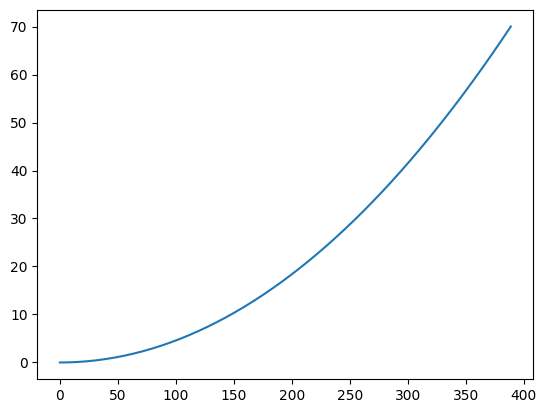

In [78]:
plt.plot(x0, z0)
plt.show()

In [79]:
q0=np.zeros(12*N)

In [80]:
for j in range(1,12):
    if j==1:
        q0[(j-1)*N:j*N]=x0
    elif j==5:
        q0[(j-1)*N:j*N]=z0

In [81]:
def static_func(Q): 
    t=0

    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    RET = Ret(φ,θ,ψ)
    
    Z1 = d_s(ne, x, y, z, φ, θ, ψ).T
    Z2 = ne_hat(x, y, z, dx, dy, dz, False).T
    Z = (Z1 + Z2 )


############################################################
    ddx,ddy, ddz = (Z/mp).T
############################################################
    
    C1 = d_s(me, φ, θ, ψ, φ, θ, ψ)
    C = (C1.T)
 
    A0 = Jrho(RET,Jrho0)
    A_fin = np.einsum('ijk,ikr->ijr',A0, Π(φ,θ,ψ))

    B = np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ,dθ,dψ), axis=1))
    
    D = w_e(φ,θ,ψ,dφ,dθ,dψ)
    # D[:, :] = 0                                                     ### !!! ### !!! ### !!! ###

    
    G = np.cross(d_s(phi,x,y,z,φ, θ, ψ).T, ne(x, y, z, φ, θ, ψ))
    L = np.einsum('ijk,ik->ij',RET, (DR@D.T).T) 
    
    H = np.cross(D,np.einsum('ijk,ik->ij', A0, D))

#############################################
    ddφ,ddθ,ddψ = np.linalg.solve(A_fin, C + G - L - H - np.einsum('ijk,ik->ij',A0, B)).T
#############################################
    
    ans=np.concatenate([dx, ddx, 
                        dy, ddy,  
                        dz, ddz, 
                        dφ, ddφ,  
                        dθ, ddθ, 
                        dψ, ddψ,  
                       ], axis=0)

    return ans

In [82]:
root_ = root(static_func, q0, method='lm')

In [83]:
root_

 message: The relative error between two consecutive iterates is at most 0.000000
 success: True
  status: 2
     fun: [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
       x: [ 0.000e+00  7.939e+00 ...  0.000e+00  0.000e+00]
   cov_x: None
  method: lm
    nfev: 609
    fjac: [[-2.540e+03  0.000e+00 ...  0.000e+00  0.000e+00]
           [ 0.000e+00 -1.406e+02 ...  0.000e+00  0.000e+00]
           ...
           [ 0.000e+00  0.000e+00 ... -0.000e+00  0.000e+00]
           [ 0.000e+00  0.000e+00 ...  0.000e+00 -0.000e+00]]
    ipvt: [201 450 ... 239 240]
     qtf: [-3.393e+02 -1.737e+00 ...  2.177e-17 -4.086e-18]

In [84]:
x0_, z0_=root_.x[:N],root_.x[4*N:5*N]

In [85]:
q0 = root_.x                                            # start from static solution

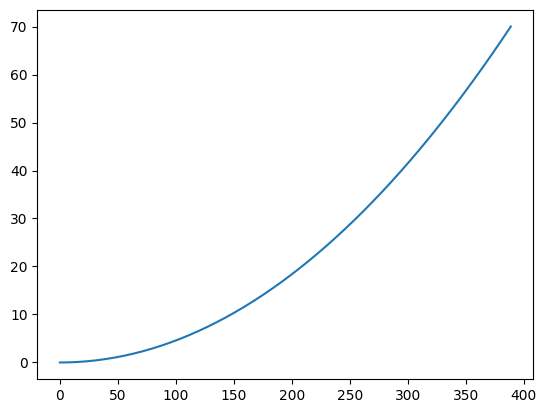

In [86]:
plt.plot(x0_, z0_)
plt.show()

### Vessle Simulation

In [87]:
sampleTime = 0.01              # sample time [seconds]
Number = 60000                      # number of samples

In [88]:
Number*sampleTime

600.0

In [89]:
vehicle=semisub('DPcontrol',1,-1,0.0,0,0)

In [90]:
[simTime, simData] = simulate(Number, sampleTime, vehicle)

In [91]:
simData.shape 

(60001, 24)

In [92]:
ans_t=[]
sum_=0
for i in range(simData.shape[0]):
    ans_t.append(sum_)
    sum_+=sampleTime

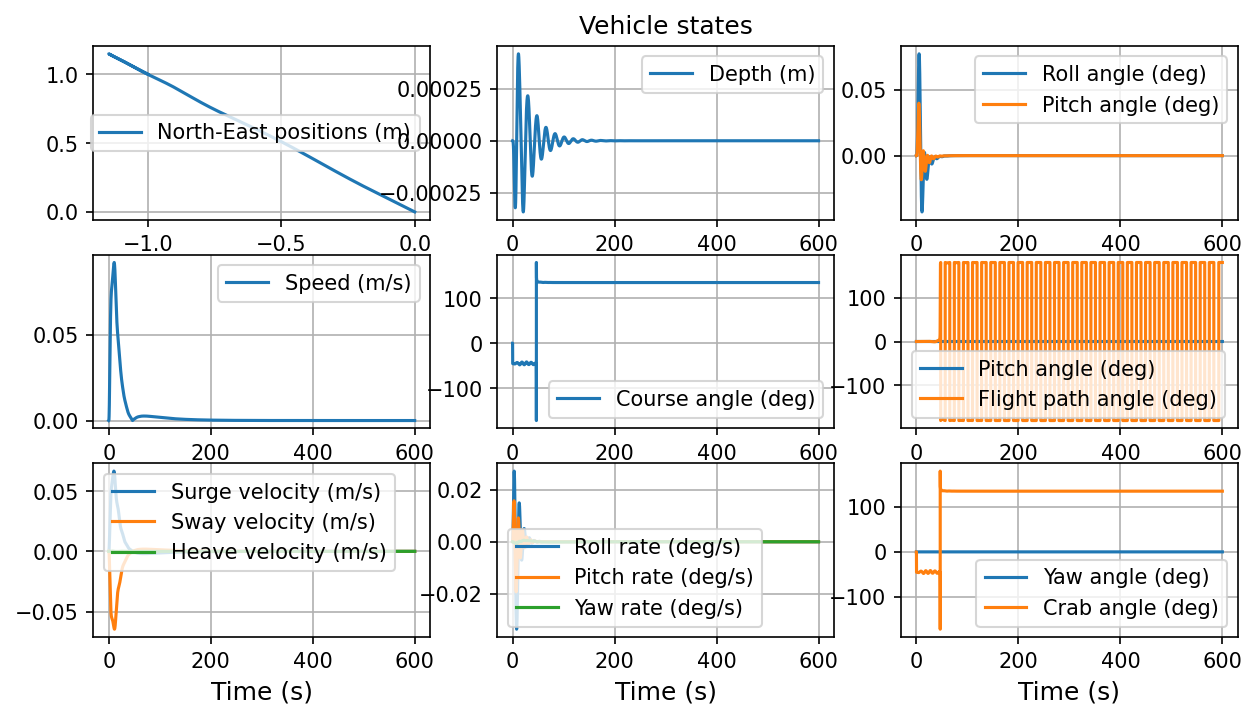

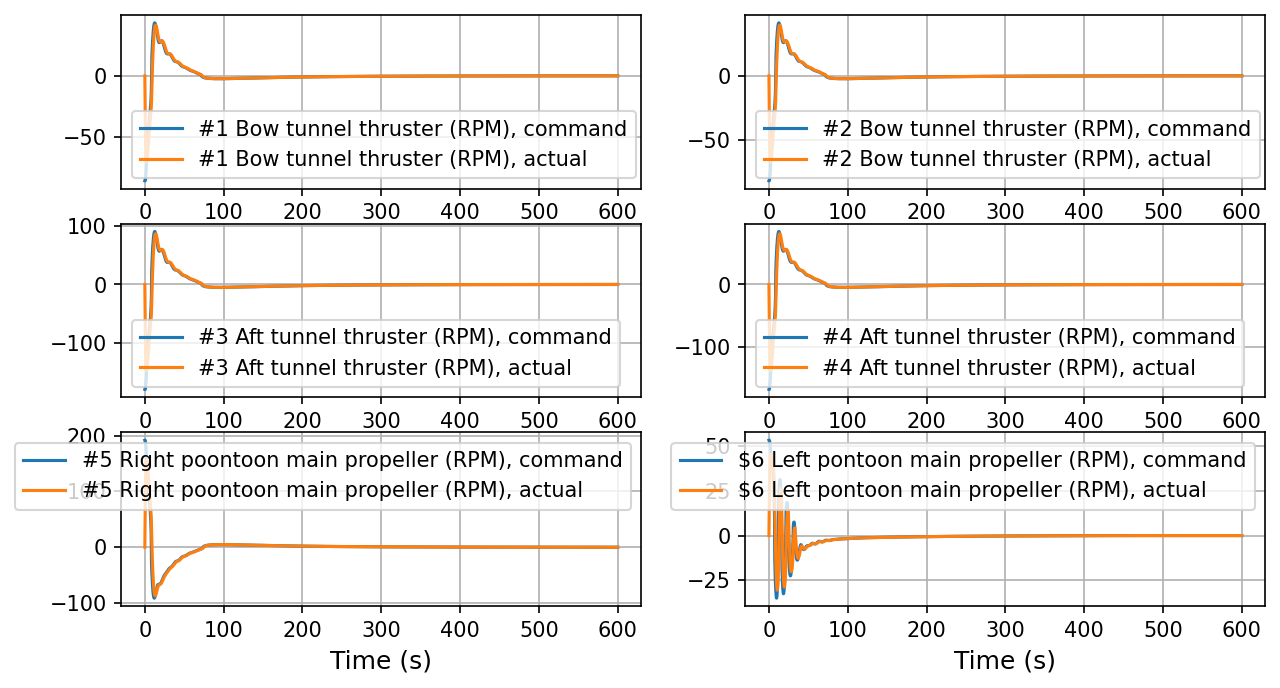

In [93]:
plotVehicleStates(simTime, simData, 1)
plotControls(simTime, simData, vehicle, 2)

In [94]:
numDataPoints = 5                 # number of 3D data points
FPS = 10                            # frames per second (animated GIF)
filename = '3D_animation.gif'       # data file for animated GIF
browser = 'safari'

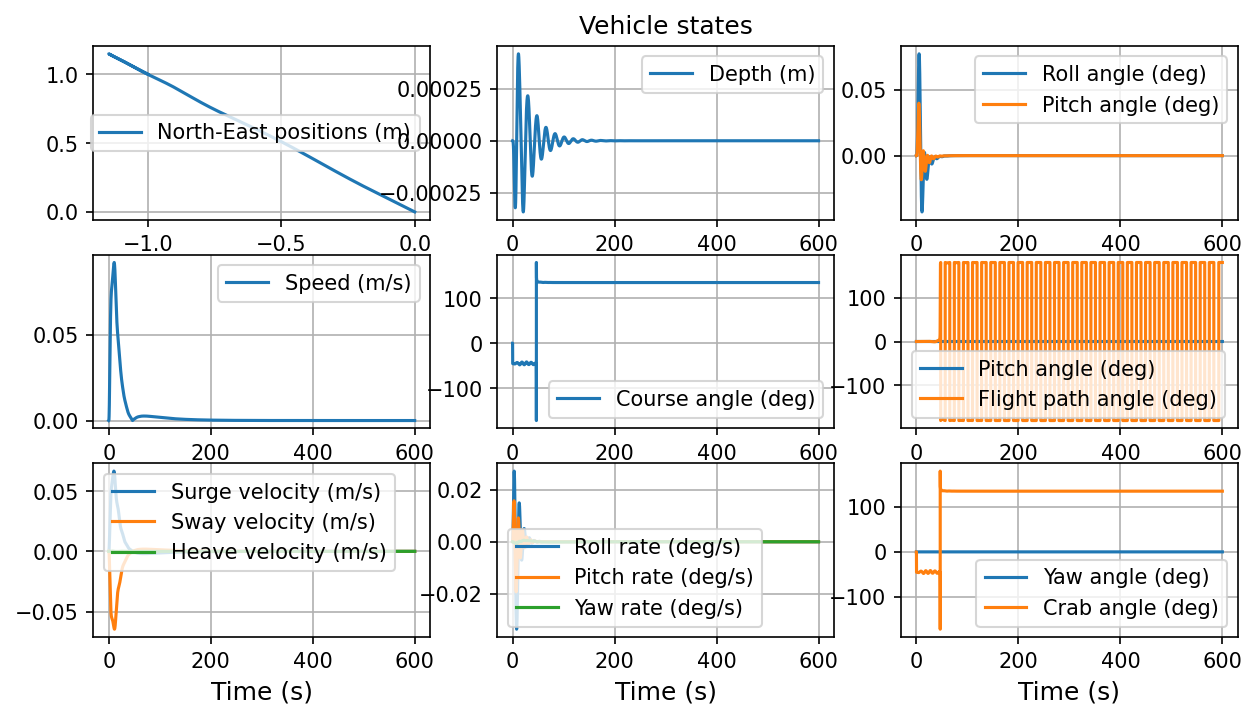

In [95]:
plotVehicleStates(simTime, simData, 3)

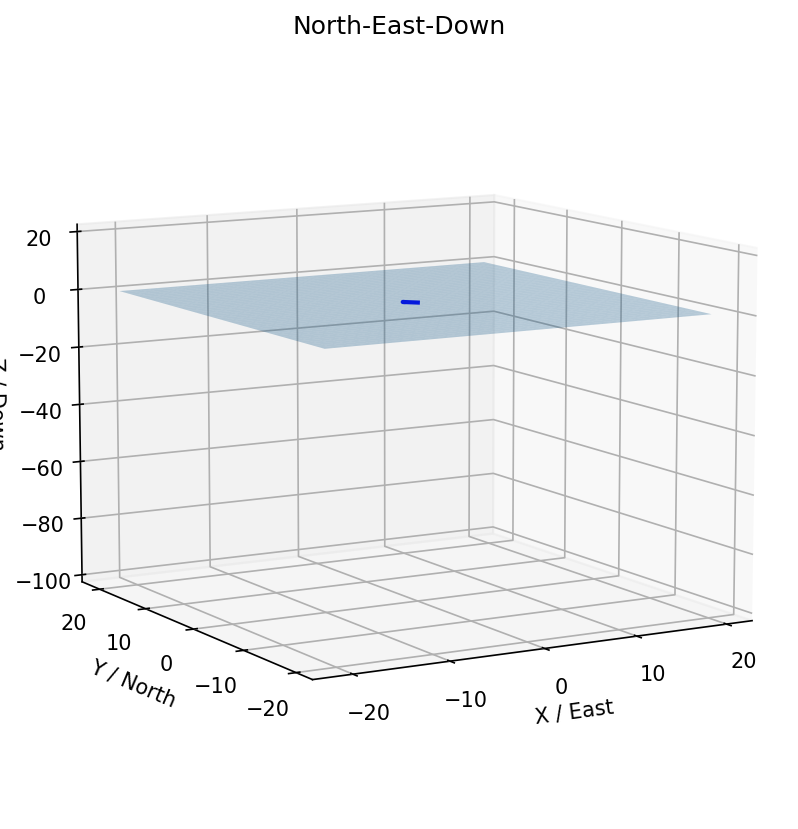

In [96]:
plot3D(simData, numDataPoints, FPS, filename, 3)

In [97]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

In [98]:
class MyTime:
    def __init__(self):
        self.my_t = 0
        self.v_m = np.array([0,0,0,0,0,0]).astype(np.float64)
        self.progression = [i for i in range(650)]
        self.wall_clock = datetime.now()
        self.x_ve = 0
        self.y_ve = 0
        self.z_ve = 0
        self.phi_ve = 0
        self.theta_ve = 0
        self.psi_ve = 0
        self.top_tension = 0
        self.sagbend_strain = 0
        self.my_iter = 0

In [99]:
vessel_motion_func = interp1d(
    ans_t, simData[:, 6:12], axis=0, kind="linear", fill_value="extrapolate"
)

### Dynamics

In [100]:
def dynamic_func(t, Q, T):
    
        
    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    ve = vessel_motion_func(t)
    dx_ve = ve[0]
    dy_ve = ve[1]
    dz_ve = ve[2]
    dphi_ve = ve[3]
    dtheta_ve = ve[4]
    dpsi_ve = ve[5]
    
    s = np.linspace(0, 1, N)
    error_x=0.1*(s*dx_ve-dx)
    error_y=0.1*(s*dy_ve-dy)
    error_z=0.1*(s*dz_ve-dz)
    dx += error_x
    dy += error_y
    dz += error_z
    
    RET = Ret(φ,θ,ψ)
    
    Z1 = d_s(ne, x, y, z, φ, θ, ψ).T
    Z2 = ne_hat(x, y, z, dx, dy, dz, False).T
    Z = (Z1 + Z2)

############################################################
    ddx,ddy, ddz = (Z/mp).T
############################################################
    
    C1 = d_s(me, φ, θ, ψ, φ, θ, ψ).T
    C = C1

    A0 = Jrho(RET,Jrho0)
    A_fin = np.einsum('ijk,ikr->ijr', A0, Π(φ,θ,ψ))
    

    B = np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ,dθ,dψ), axis=1))

    error_φ=0.1*(s*dphi_ve-dφ)
    error_θ=0.1*(s*dtheta_ve-dθ)
    error_ψ=0.1*(s*dpsi_ve-dψ)
    dφ += error_φ
    dθ += error_θ
    dψ += error_ψ
    
    D = w_e(φ,θ,ψ,dφ,dθ,dψ)
    
    G = np.cross(d_s(phi,x,y,z,φ, θ, ψ).T, ne(x, y, z, φ, θ, ψ))
    
    L = np.einsum('ijk,ik->ij',RET, (DR@D.T).T) 

    H = np.cross(D, np.einsum('ijk,ik->ij', A0, D))
    

#############################################
    ddφ,ddθ,ddψ = np.linalg.solve(A_fin, (C + G - L - H - np.einsum('ijk,ik->ij', A0, B))).T
#############################################


    if t>T.progression[0]:
        T.progression.pop(0)
        print('Physical time: ', t, ' Iteration wall-clock time: ', datetime.now() - T.wall_clock )
        T.wall_clock = datetime.now()   
         

    ans=np.concatenate([dx, ddx, 
                            dy, ddy, 
                            dz, ddz, 
                            dφ, ddφ, 
                            dθ, ddθ,  
                            dψ, ddψ, 
                           ], axis=0)
   
   
    if t>1:
        ax=np.einsum('ijk,ik->ij',np.linalg.inv(RET),ne(x, y, z, φ, θ, ψ))
       
        T.top_tension=max(T.top_tension, np.max(ax[:,0]))            
        
        ben0=np.einsum('ijk,ik->ij',np.linalg.inv(RET), me(φ, θ, ψ, φ, θ, ψ))
        ben=np.max(ben0[:,1:])
        
        I=3.14*(d0**4-dI**4)/64
        strain=np.max(ben)*d0/(2*E*I)    
        
        T.sagbend_strain=max(T.sagbend_strain, strain)
    T.my_iter+=1
    
 
    return ans

In [101]:
T_ = MyTime()

# initial conditions - to control dynamics
q0[6*N:7*N], q0[8*N:9*N], q0[10*N:11*N] = (np.array([0.01 for i in range(N)]),
                                          np.array([0.00003 for i in range(N)]),
                                          np.array([0.001767*i/N for i in range(N)]))

In [102]:
startTime1 = datetime.now()
us_ = solve_ivp(dynamic_func,
             tspan,
             q0,
             args=(T_, ), 
               )
print(datetime.now() - startTime1)

Physical time:  6.0291006360917624e-09  Iteration wall-clock time:  0:00:00.019948
Physical time:  1.0020894047989082  Iteration wall-clock time:  0:00:02.746329
Physical time:  2.007027919300379  Iteration wall-clock time:  0:00:02.691609
Physical time:  3.00291883112064  Iteration wall-clock time:  0:00:02.858272
Physical time:  4.001017611853331  Iteration wall-clock time:  0:00:02.796317
Physical time:  5.000713817392508  Iteration wall-clock time:  0:00:02.608824
Physical time:  6.001548346843029  Iteration wall-clock time:  0:00:02.849862
Physical time:  7.0001566377776445  Iteration wall-clock time:  0:00:03.206904
Physical time:  8.000006692128096  Iteration wall-clock time:  0:00:04.072499
Physical time:  9.00469126091266  Iteration wall-clock time:  0:00:02.981894
0:00:29.048000


### Results

In [103]:
# max axial tension
T_.top_tension

314368.9848952469

In [104]:
# max bending strain
T_.sagbend_strain

0.01071398580666355

In [105]:
fin=us_

In [106]:
fin

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  6.029e-07 ...  9.987e+00  1.000e+01]
        y: [[ 0.000e+00  1.083e-25 ...  8.867e-03  8.881e-03]
            [ 7.939e+00  7.939e+00 ...  7.887e+00  7.887e+00]
            ...
            [ 0.000e+00 -6.454e-21 ... -7.204e-06 -7.236e-06]
            [ 0.000e+00  2.886e-23 ... -7.354e-06 -7.387e-06]]
      sol: None
 t_events: None
 y_events: None
     nfev: 3080
     njev: 0
      nlu: 0

In [107]:
t=fin.t

In [108]:
fin=fin.y.T

In [109]:
t.shape, fin.shape

((500,), (500, 600))

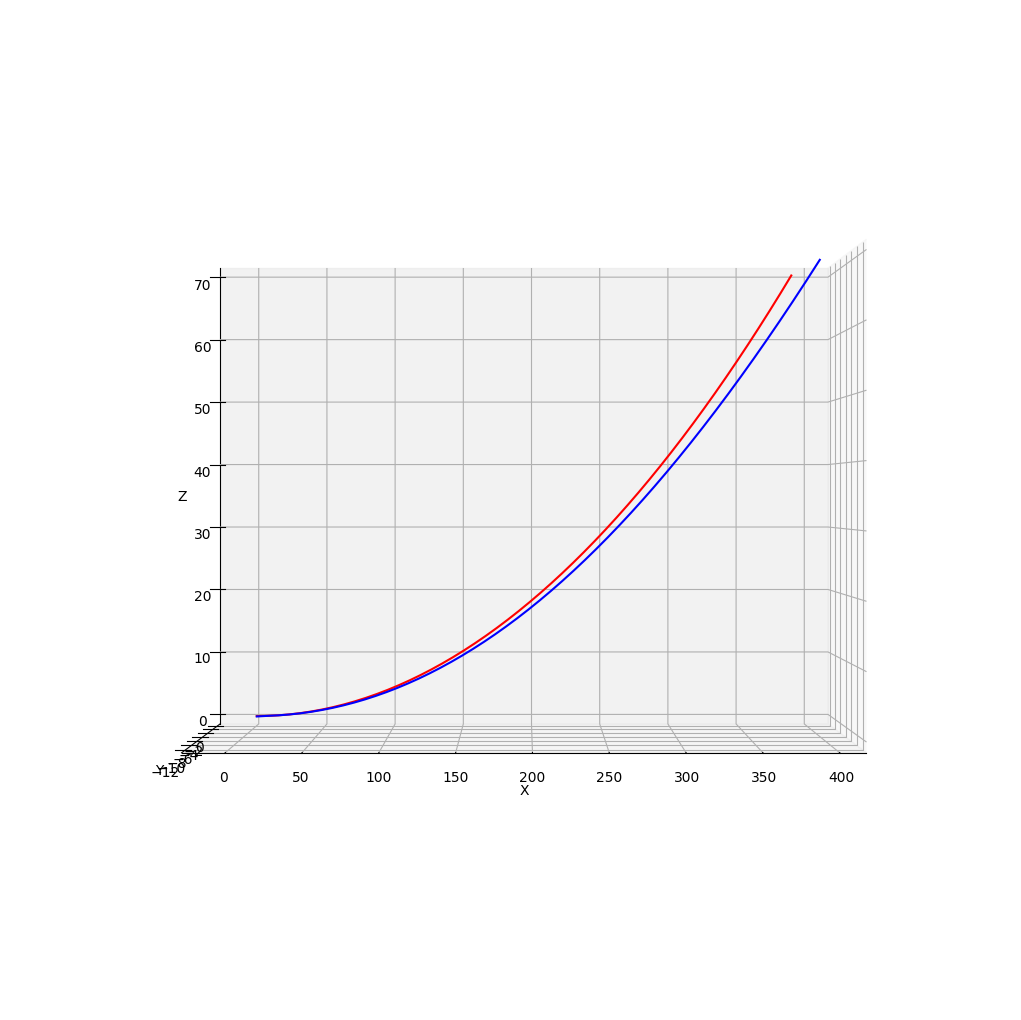

In [110]:
fig=plt.figure(figsize=(13,13))
ax = fig.add_subplot(projection = '3d')

X0=fin[0,[i for i in range(0,N)]]
Y0=fin[0,[i for i in range(2*N,3*N)]]
Z0=fin[0,[i for i in range(4*N,5*N)]]

j=-1
X=fin[j,[i for i in range(0,N)]]
Y=fin[j,[i for i in range(2*N,3*N)]]
Z=fin[j,[i for i in range(4*N,5*N)]]

num_true_pts = 200
tck, u = interpolate.splprep([X,Y,Z], s=2)
u_fine = np.linspace(0,1,num_true_pts)
x_fine, y_fine, z_fine = interpolate.splev(u_fine, tck)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.plot(X0,Y0,Z0, color='r')
ax.plot(X,Y,Z, color='b')
ax.view_init(0,-90)
plt.show()

In [111]:
X,Y,Z

(array([8.88111319e-03, 7.88714679e+00, 1.57744918e+01, 2.36626186e+01,
        3.15515935e+01, 3.94414941e+01, 4.73324067e+01, 5.52244238e+01,
        6.31176439e+01, 7.10121696e+01, 7.89081038e+01, 8.68055494e+01,
        9.47046113e+01, 1.02605383e+02, 1.10507945e+02, 1.18412368e+02,
        1.26318713e+02, 1.34227014e+02, 1.42137300e+02, 1.50049570e+02,
        1.57963804e+02, 1.65879998e+02, 1.73798154e+02, 1.81718135e+02,
        1.89639723e+02, 1.97562709e+02, 2.05486858e+02, 2.13412071e+02,
        2.21338342e+02, 2.29265693e+02, 2.37194334e+02, 2.45124556e+02,
        2.53056864e+02, 2.60992012e+02, 2.68931119e+02, 2.76874614e+02,
        2.84822282e+02, 2.92773975e+02, 3.00729751e+02, 3.08690154e+02,
        3.16655706e+02, 3.24626881e+02, 3.32604078e+02, 3.40587455e+02,
        3.48576674e+02, 3.56568906e+02, 3.64561341e+02, 3.72553961e+02,
        3.80548088e+02, 3.88545903e+02]),
 array([ 2.66433474e-05,  1.83516469e-02,  2.60660434e-02,  2.31068379e-02,
         9.4357511

In [112]:
X0,Y0,Z0

(array([  0.        ,   7.93932869,  15.87865737,  23.81798606,
         31.75731475,  39.69664344,  47.63597212,  55.57530081,
         63.5146295 ,  71.45395818,  79.39328687,  87.33261556,
         95.27194424, 103.21127293, 111.15060162, 119.08993031,
        127.02925899, 134.96858768, 142.90791637, 150.84724505,
        158.78657374, 166.72590243, 174.66523111, 182.6045598 ,
        190.54388849, 198.48321718, 206.42254586, 214.36187455,
        222.30120324, 230.24053192, 238.17986061, 246.1191893 ,
        254.05851798, 261.99784667, 269.93717536, 277.87650405,
        285.81583273, 293.75516142, 301.69449011, 309.63381879,
        317.57314748, 325.51247617, 333.45180485, 341.39113354,
        349.33046223, 357.26979092, 365.2091196 , 373.14844829,
        381.08777698, 389.02710566]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.

In [113]:
us=fin.T

In [114]:
us.shape

(600, 500)

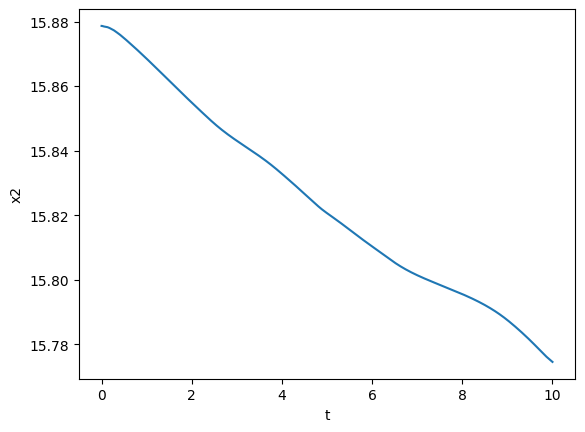

In [115]:
plt.plot(t,us.T[:,2],'-')
plt.xlabel('t')
plt.ylabel('x2')
plt.show()

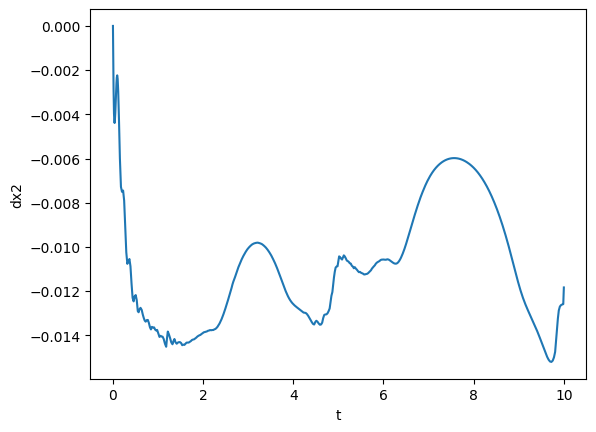

In [116]:
plt.plot(t,us.T[:,N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dx2')
plt.show()

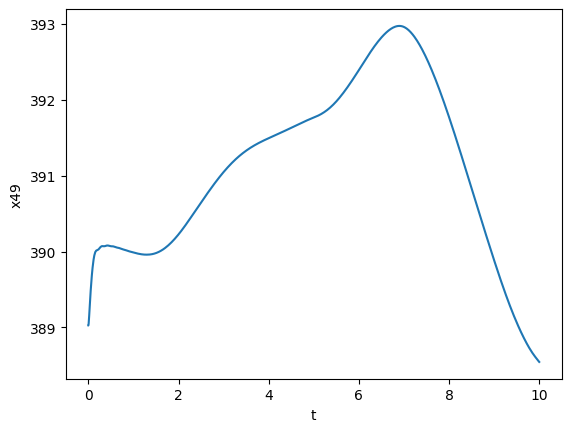

In [117]:
plt.plot(t,us.T[:,N-1] ,'-')
plt.xlabel('t')
plt.ylabel('x{}'.format(N-1))
plt.show()

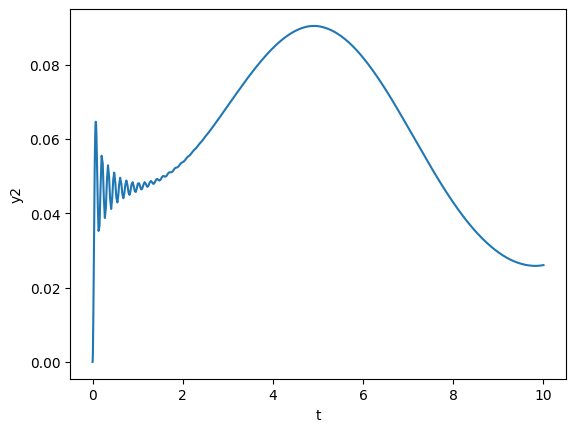

In [118]:
plt.plot(t,us.T[:,2*N +2] ,'-')
plt.xlabel('t')
plt.ylabel('y2')
plt.show()

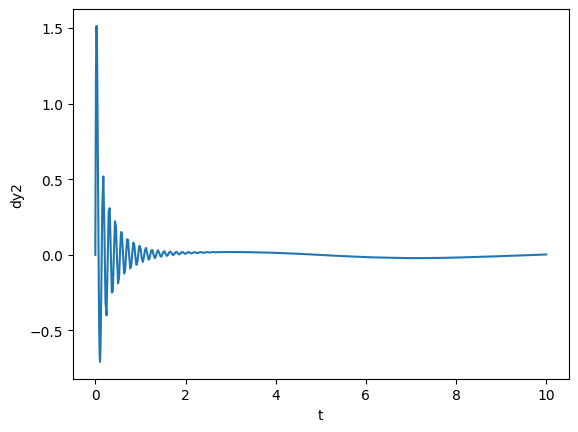

In [119]:
plt.plot(t,us.T[:,3*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dy2')
plt.show()

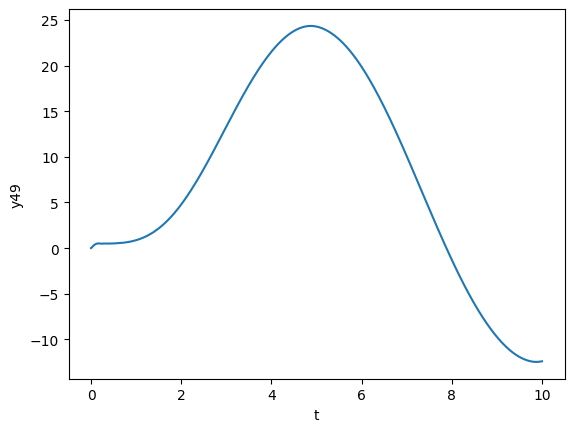

In [120]:
plt.plot(t,us.T[:,2*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('y{}'.format(N-1))
plt.show()

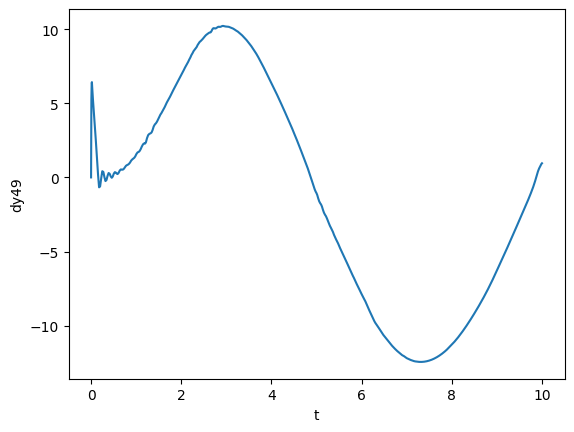

In [121]:
plt.plot(t,us.T[:,3*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('dy{}'.format(N-1))
plt.show()

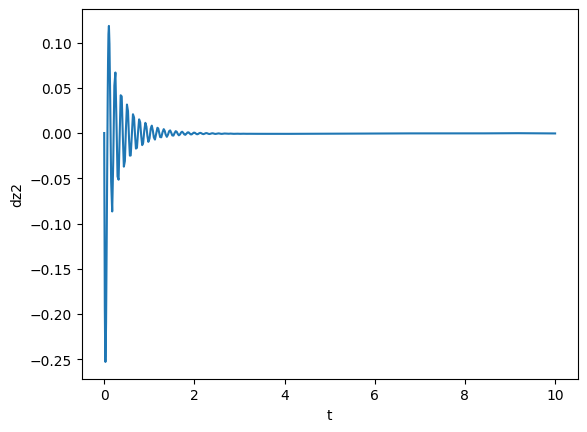

In [122]:
plt.plot(t,us.T[:,5*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dz2')
plt.show()

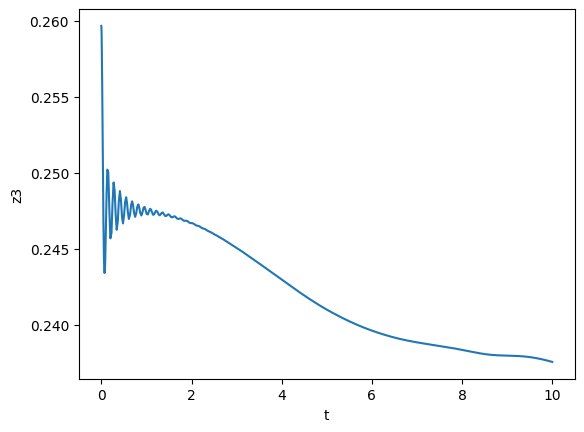

In [123]:
plt.plot(t,us.T[:,4*N+3] ,'-')
plt.xlabel('t')
plt.ylabel('z3')
plt.show()

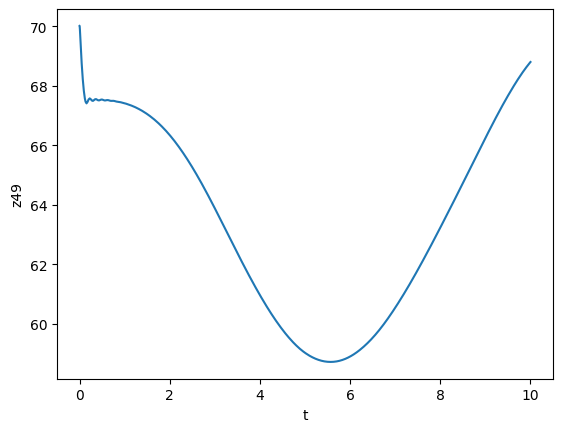

In [124]:
plt.plot(t,us.T[:,4*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('z{}'.format(N-1))
plt.show()

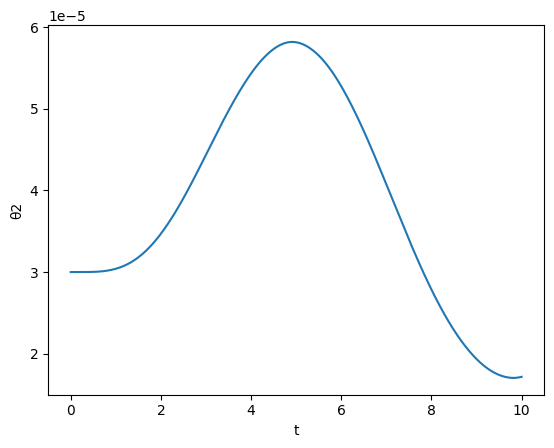

In [125]:
plt.plot(t,us.T[:,8*N+2],'-')
plt.xlabel('t')
plt.ylabel('θ2')
plt.show()

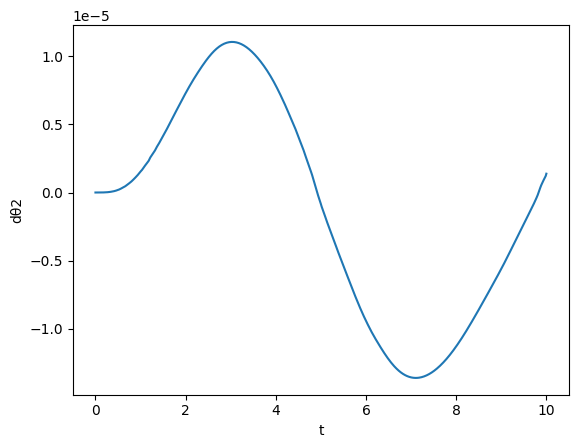

In [126]:
plt.plot(t,us.T[:,9*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dθ2')
plt.show()

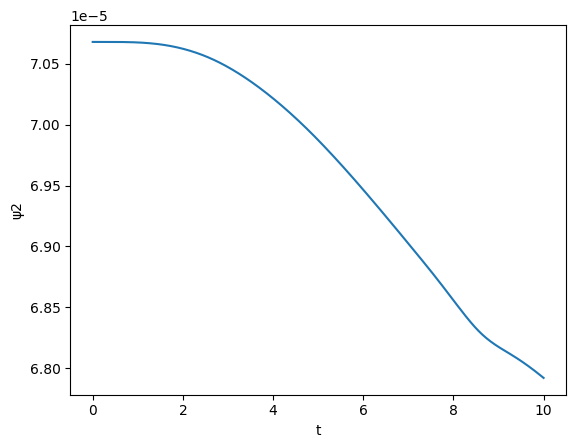

In [127]:
plt.plot(t,us.T[:,10*N+2],'-')
plt.xlabel('t')
plt.ylabel('ψ2')
plt.show()

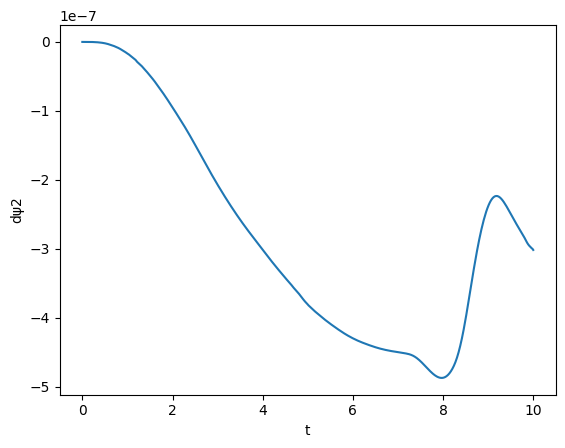

In [128]:
plt.plot(t,us.T[:,11*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dψ2')
plt.show()

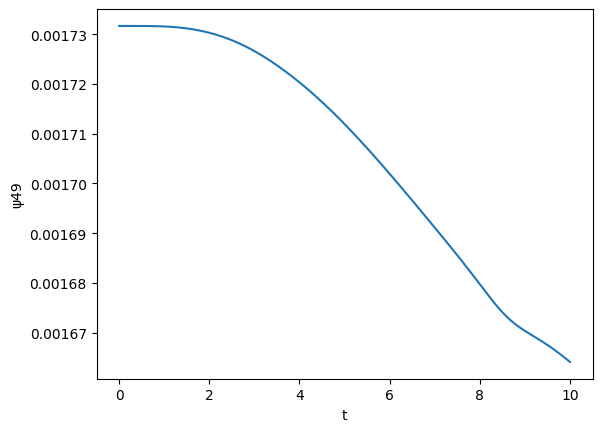

In [129]:
plt.plot(t,us.T[:,10*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('ψ{}'.format(N-1))
plt.show()

In [130]:
X010=us.T[:,0*N:1*N]

In [131]:
Y010=us.T[:,2*N:3*N]

In [132]:
Z010=us.T[:,4*N:5*N]

In [133]:
# simulation = np.stack([X010,Y010,Z010],axis=2) 

# FPS = 5                      
# frame_duration = 1000 / FPS

# frames = []
# for t in range(simulation.shape[0]):
#     x = simulation[t,:,0]
#     y = simulation[t,:,1]
#     z = simulation[t,:,2]

#     frames.append(go.Frame(
#         data=[
#             go.Scatter3d(
#                 x=x, y=y, z=z,
#                 mode="lines+markers",
#                 marker=dict(size=5, color=list(range(12)), colorscale="Viridis"),
#                 line=dict(width=4)
#             )
#         ],
#         name=f"t={t}"
#     ))

# # First frame
# x0, y0, z0 = simulation[0,:,0], simulation[0,:,1], simulation[0,:,2]

# fig = go.Figure(
#     data=[go.Scatter3d(x=x0, y=y0, z=z0, mode="lines+markers")],
#     frames=frames
# )

# # Animation controls
# fig.update_layout(
#     title="Pipeline Simulation ",
#     scene=dict(
#         xaxis_title="X",
#         yaxis_title="Y",
#         zaxis_title="Z",
#         xaxis=dict(range=[0, 400]),
#         yaxis=dict(range=[-50, 50]),
#         zaxis=dict(range=[0, 100]),
#         aspectmode="data",
       
#     ),
#     updatemenus=[{
#         "type": "buttons",
#         "buttons": [
#             {
#                 "label": "Play",
#                 "method": "animate",
#                 "args": [None, {"frame": {"duration": frame_duration, "redraw": True}}]
#             },
#             {
#                 "label": "Pause",
#                 "method": "animate",
#                 "args": [[None], {"frame": {"duration": 0}}]
#             }
#         ]
#     }]
# )

# fig.show()